# Import the libraries and configure a spark session

In [1]:
from pyspark.sql import SparkSession
import os
import pyspark.sql.functions as sf
from pyspark.sql import Window

In [2]:
# Get the access and secret keys to connect to s3
access_key = os.getenv("S3_ACCESS_KEY")
secret_key = os.getenv("S3_SECRET_KEY") 

# Create a spark session including modules to connect to s3
# Added the third line in which I can set manually the memory usage for each worker
spark = SparkSession.builder \
    .master("spark://master:7077")\
    .appName("Anomaly Detection")\
    .config('spark.jars.packages', 'org.apache.hadoop:hadoop-aws:3.4.1,org.apache.hadoop:hadoop-common:3.4.1')\
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")\
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")\
    .config('spark.hadoop.fs.s3a.aws.credentials.proviAnvoder', 'org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider')\
    .config('spark.hadoop.fs.s3a.access.key', access_key)\
    .config('spark.hadoop.fs.s3a.secret.key', secret_key)\
    .config('spark.hadoop.fs.s3a.endpoint', 'https://cloud-areapd.pd.infn.it:5210')\
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.metadatastore.impl", "org.apache.hadoop.fs.s3a.s3guard.NullMetadataStore") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled","false") \
    .config("com.amazonaws.sdk.disableCertChecking","true") \
    .getOrCreate()

:: loading settings :: url = jar:file:/usr/local/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/ubuntu/.ivy2.5.2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
org.apache.hadoop#hadoop-common added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-cd141d28-ab92-4f67-9a62-d396c5d01b6e;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.hadoop#hadoop-common;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-protobuf_3_25;1.3.0 in central
	found org.apache.hadoop#hadoop-annotations;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-guava;1.3.0 in central
	found com.google.guava#guava;27.0-jre in central
	found com.google.guava#failureacce

# Task 1: conversion of alarms

First of all, we will convert the "A5" and "A9" variables from their integer representation to their bit string one. This will help identifying the required alarms. \
First, we have to read the data file from the CloudVeneto "bucket", converted into the *Parquet* format by  `df_spark.write.mode("overwrite").parquet("s3a://MAPDB-Group5/data_parquet")`

In [4]:
# Read data from the CloudVeneto "bucket" through s3
df_spark = spark.read.parquet("s3a://MAPDB-Group5/data_parquet")
df_spark.show(10)

+-------------+------+------+-----+
|         when|  hwid|metric|value|
+-------------+------+------+-----+
|1604265597702|SW-115|   S80|    0|
|1604265597702|SW-115|   S73|    0|
|1604265597702|SW-115|   S72|  100|
|1604265597702|SW-115|   S71|  100|
|1604265597702|SW-115|   P16|  200|
|1604265597702|SW-115|   P15|    0|
|1604265597702|SW-115|   P10|  430|
|1604265597702|SW-115|    P9|  300|
|1604265597702|SW-115|    P8|  150|
|1604265597702|SW-115|    P7|  260|
+-------------+------+------+-----+
only showing top 10 rows


After reading the data, we can convert the `A5` and `A9` metrics to their bitwise representation

In [4]:
# Converting the A5 and A9 metrics to their bit-string representation
# Note: all the other values are converted into strings because Spark
# wants the same type returned by when/otherwise 
df_spark = df_spark.withColumn(
    "BitString",
    sf.when(
        df_spark.metric.isin('A5', 'A9'),
        sf.lpad(sf.bin(df_spark.value), 16, '0')
    ).otherwise(df_spark.value.cast('string'))
)

Now that we have converted the `A5` and `A9` variables to their bit-string representation, we can identify the requested alarms by checking if 1+ bit(s) in position 6, 7 and 8 (staring from the LSB), are 1 in either or both of them, which means that engines are overheating.

In [5]:
# Starting from the LSB, positions 6, 7 and 8 correspond to position 9, 10 and 11
# because the substring function operates from left to right (so from the MSB)
df_spark = df_spark.withColumn(
    "is_overheated",
    sf.when(
        df_spark.metric.isin('A5', 'A9') & 
        (sf.substring(df_spark.BitString, 9, 3) != '000'),
        True
    ).otherwise(False)
)

After identifying all the requested alarms and flagging them with `is_overheated`, we can resample all the metrics to the same sampling frequency, in order to correctly conduct the analysis. \
We chose the sampling frequence to be **1 minute**

In [6]:
# Overwrite the "when" column, representing a UNIX timestamp, casting that to the native "TimestampType"
# using the native spark function
df_spark = df_spark.withColumn(
    "when",
    sf.timestamp_millis(df_spark.when)
)

# Now let's add a "timestamp_bucket" column, "truncating" everything to the minutes
# to get the same sampling frequency for all data
df_spark = df_spark.withColumn(
    "timestamp_bucket",
    sf.date_trunc("minute", "when")
)

# Use flag "truncate=False" to show the whole timestamp
df_spark.show(10, truncate=False)

+-----------------------+------+------+-----+---------+-------------+-------------------+
|when                   |hwid  |metric|value|BitString|is_overheated|timestamp_bucket   |
+-----------------------+------+------+-----+---------+-------------+-------------------+
|2020-11-01 21:19:57.702|SW-115|S80   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S73   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S72   |100  |100      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S71   |100  |100      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P16   |200  |200      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P15   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P10   |430  |430      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P9    |300  |300      |false        |2020-11-01 21:19:00|
|2020-11-0

Now that we have added a `timestamp_bucket`, we need to aggregate all the metrics under the same bucket. 
To do so, we will use the following strategy, which takes into account the nature of the data:

* **Engine status metrics (S117, S118, S169, S170):** these metrics indicate the ON/OFF power state of the engines (engine 1, 2, 3, and 4, respectively). To aggregate them within a single bucket, we use the **maximum value** detected by the system. This guarantees that if an engine was active at any point during that interval, the state is recorded as active (`1`).

* **Discrete states, binary flags, and alarms (e.g., operational modes, valve statuses, and the `is_overheated` flag):** we also aggregate these using the **maximum value** (acting as a logical OR). This ensures that any alarm event or state transition occurring within the bucket is preserved rather than smoothed out.

* **Continuous physical measurements (e.g., temperatures, pressures, powers, and capacities such as S41, S100, S102, S109, S125, E1):** we aggregate these using the **mean value** Now that we have added a `timestamp_bucket`, we need to aggregate all the metrics under the same bucket. 
To do so, we will use the following strategy, which takes into account the nature of the data:

* **Cumulative energy counters (E3, E4, E5, E6):** since these variables represent monotonically increasing cumulative readings, we aggregate them using the **maximum value** to reflect the total accumulated energy at the end of the interval.

In [7]:
# List of all the metrics that should be aggregated using their mean
continuous_metrics = [
    'E1', 'E2',
    'S19', 'S37', 'S39', 'S40', 'S41', 'S42', 'S43', 'S45', 'S46', 'S47', 'S49', 'S50',
    'S69', 'S70', 'S71', 'S72', 'S80', 'S81', 'S83', 'S86', 'S90', 'S94', 'S97',
    'S100', 'S101', 'S102', 'S106', 'S107', 'S108', 'S109', 'S110',
    'S122', 'S124', 'S125', 'S126', 'S128', 'S129',
    'S137', 'S138', 'S140', 'S143', 'S147',
    'S151', 'S154', 'S157', 'S158', 'S159',
    'S163', 'S164', 'S165', 'S166', 'S167',
    'S178', 'S180', 'S181'
]

# Define a window partitioned by timestamp_bucket and device (hwid).
# We omit orderBy and framing to allow Spark to compute the partition-level max
# without maintaining strict ordering, keeping memory overhead minimal.
w_device = Window.partitionBy("timestamp_bucket", "hwid")

# Propagate the "is_overheated" flag across all records belonging to the same device 
# and bucket window. If any alarm (e.g., 'A5' or 'A9') flagged overheating, 
# all rows in that bucket/device will receive True.
df_with_flag = df_spark.withColumn(
    "is_overheated_device",
    sf.max(sf.col("is_overheated")).over(w_device)
)

# It's important to also groupBy "hwid" which indicates the specific device.
# We use the "coalesce" function because if the metric isn't in the "continuous_metrics" list
# the first expression will implicitly return "null".
# Coalesce returns the first not null value, so if the metric isn't in that list, it will
# automatically pass to the second value and return the max
df_aggregated = (
    df_with_flag.groupBy("timestamp_bucket", "hwid", "metric")
      .agg(
          sf.coalesce(
              sf.mean(sf.when(sf.col("metric").isin(continuous_metrics), sf.col("value"))),
              sf.max(sf.col("value"))
          ).alias("aggregated_value"),
          sf.first("is_overheated_device").alias("is_overheated")
      )
)

df_aggregated.show(10)

+-------------------+------+------+----------------+-------------+
|   timestamp_bucket|  hwid|metric|aggregated_value|is_overheated|
+-------------------+------+------+----------------+-------------+
|2020-10-01 00:08:00|SW-088|    P1|             0.0|        false|
|2020-10-01 00:08:00|SW-088|   P10|           450.0|        false|
|2020-10-01 00:08:00|SW-088|   P15|             0.0|        false|
|2020-10-01 00:08:00|SW-088|   P16|           125.0|        false|
|2020-10-01 00:08:00|SW-088|   P17|           400.0|        false|
|2020-10-01 00:08:00|SW-088|   P18|           450.0|        false|
|2020-10-01 00:08:00|SW-088|    P2|             0.0|        false|
|2020-10-01 00:08:00|SW-088|    P5|           300.0|        false|
|2020-10-01 00:08:00|SW-088|    P6|           180.0|        false|
|2020-10-01 00:08:00|SW-088|    P7|           260.0|        false|
+-------------------+------+------+----------------+-------------+
only showing top 10 rows


## **Anomaly detection 1**

In [12]:
# Read data from the CloudVeneto "bucket" through s3
df_spark = spark.read.parquet("s3a://MAPDB-Group5/data_parquet")
#df_spark.show(10)
df_spark.printSchema()

root
 |-- when: long (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- value: integer (nullable = true)



In [13]:
# Overwrite the "when" column, representing a UNIX timestamp, casting that to the native "TimestampType"
# using the native spark function
df_spark = df_spark.withColumn(
    "when",
    sf.timestamp_millis(df_spark.when)
)

# Now let's add a "timestamp_bucket" column, "truncating" everything to the minutes
# to get the same sampling frequency for all data
df_spark = df_spark.withColumn(
    "timestamp_bucket",
    sf.date_trunc("minute", "when")
)

df_spark.printSchema()

root
 |-- when: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- value: integer (nullable = true)
 |-- timestamp_bucket: timestamp (nullable = true)



In [14]:
# List of all the metrics that should be aggregated using their mean
continuous_metrics = [
    'E1', 'E2',
    'S19', 'S37', 'S39', 'S40', 'S41', 'S42', 'S43', 'S45', 'S46', 'S47', 'S49', 'S50',
    'S69', 'S70', 'S71', 'S72', 'S80', 'S81', 'S83', 'S86', 'S90', 'S94', 'S97',
    'S100', 'S101', 'S102', 'S106', 'S107', 'S108', 'S109', 'S110',
    'S122', 'S124', 'S125', 'S126', 'S128', 'S129',
    'S137', 'S138', 'S140', 'S143', 'S147',
    'S151', 'S154', 'S157', 'S158', 'S159',
    'S163', 'S164', 'S165', 'S166', 'S167',
    'S178', 'S180', 'S181'
]

# It's important to also groupBy "hwid" which indicates the specific device.
# We use the "coalesce" function because if the metric isn't in the "continuous_metrics" list
# the first expression will implicitly return "null".
# Coalesce returns the first not null value, so if the metric isn't in that list, it will
# automatically pass to the second value and return the max
df_aggregated = (
    df_spark.groupBy("timestamp_bucket", "hwid", "metric")
      .agg(
          sf.coalesce(
              sf.mean(sf.when(sf.col("metric").isin(continuous_metrics), sf.col("value"))),
              sf.max(sf.col("value"))
          ).alias("aggregated_value")
      )
)

#df_aggregated.show(10)
df_aggregated.printSchema()

root
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- aggregated_value: double (nullable = true)



In [15]:
# I select only the variables needed for this task

target_metrics = ["S117", "S118", "S169", "S170"]
df_anomaly1 = df_aggregated.where(df_aggregated.metric.isin(target_metrics))

In [16]:
import pyspark.sql.functions as F
from pyspark.sql.functions import col, date_trunc
from pyspark.sql.types import IntegerType

df_anomaly1 = df_anomaly1.withColumn(
    "hour_bucket", 
    date_trunc("hour", col("timestamp_bucket"))
)

df_anomaly1.printSchema()

root
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- aggregated_value: double (nullable = true)
 |-- hour_bucket: timestamp (nullable = true)



In [17]:
# 1. Group by the hour, device, and metric to break the data into tiny chunks
# We collect the timestamp and value into a mini-table (struct) inside a list
df_grouped = df_anomaly1.groupBy("hour_bucket", "hwid", "metric").agg(
    F.collect_list(
        F.struct("timestamp_bucket", "aggregated_value")
    ).alias("time_series")
)

# 2. Sort the 60-minute array chronologically (this happens instantly in memory)
df_sorted = df_grouped.withColumn(
    "time_series_sorted", 
    F.array_sort("time_series")
)

# 3. Create a simple Python function (UDF) to count the switches in that small list
def count_switches(time_series):
    if not time_series or len(time_series) < 2:
        return 0
    switches = 0
    # Iterate through the minutes in the hour
    for i in range(1, len(time_series)):
        # Compare current minute's value to the previous minute's value
        if time_series[i].aggregated_value != time_series[i-1].aggregated_value:
            switches += 1
    return switches

# Register the Python function as a PySpark UDF
count_switches_udf = F.udf(count_switches, IntegerType())

# 4. Apply the function to get the final count!
df_hourly_frequency = df_sorted.withColumn(
    "total_state_switches", 
    count_switches_udf(F.col("time_series_sorted"))
).drop("time_series", "time_series_sorted") # Clean up the temporary columns

df_hourly_frequency.printSchema()

root
 |-- hour_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- total_state_switches: integer (nullable = true)



In [20]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

bin_width = 1

# 1. Create a new column assigning each row to a bin
df_binned = df_hourly_frequency.withColumn(
    "switch_bin", 
    (F.col("total_state_switches") / bin_width).cast("integer") * bin_width
)

# 2. Group by the new bin column and count how many hourly buckets fall into it
df_histogram_data = df_binned.groupBy("switch_bin") \
                             .count() \
                             .orderBy("switch_bin")

df_histogram_data.printSchema()

root
 |-- switch_bin: integer (nullable = true)
 |-- count: long (nullable = false)



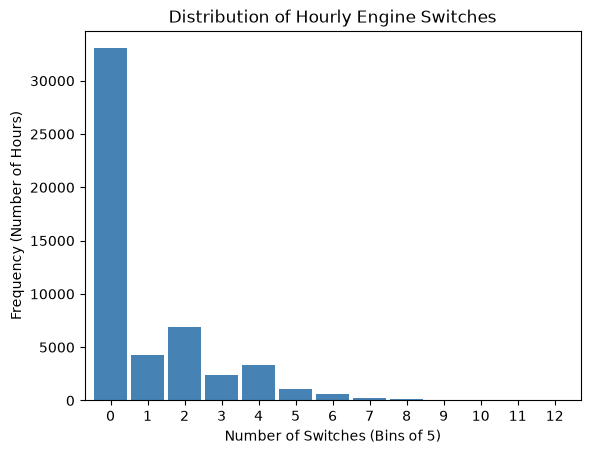

In [21]:
# 3. Bring the aggregated data to the driver as a Pandas DataFrame
# (This is perfectly safe and fast because there are very few bins)
pdf_hist = df_histogram_data.toPandas()

# 4. Plot the results using Pandas' built-in matplotlib wrapper
pdf_hist.plot(
    kind='bar', 
    x='switch_bin', 
    y='count', 
    title='Distribution of Hourly Engine Switches',
    xlabel='Number of Switches (Bins of 5)',
    ylabel='Frequency (Number of Hours)',
    legend=False,
    color='steelblue',
    width=0.9
)
plt.xticks(rotation=0)
plt.show()

In [4]:
spark.stop()